Initializing models...

--- Running Parity Plot Analysis ---
Loading and splitting data...
Evaluating models...
Generating Parity Plot...


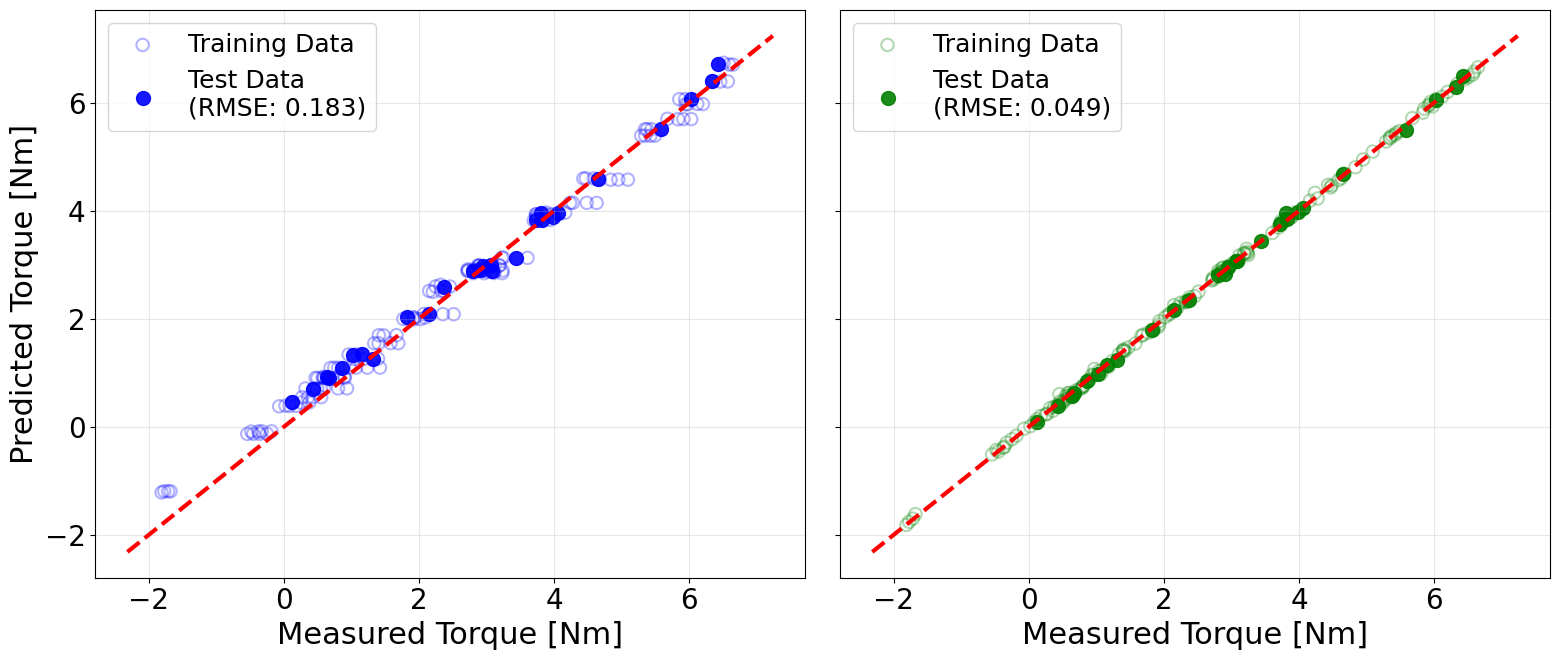


--- Calculating Baseline Grid ---
Loading Baseline...
Plotting Baseline...


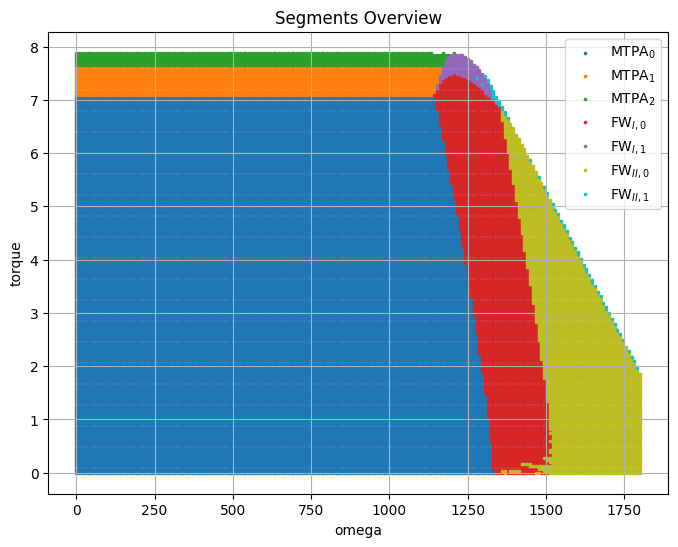


--- Calculating Correction Grid (PIRN Output) ---
Loading Correction Grid...
Plotting Correction Grid (Y-Axis = PIRN Output)...


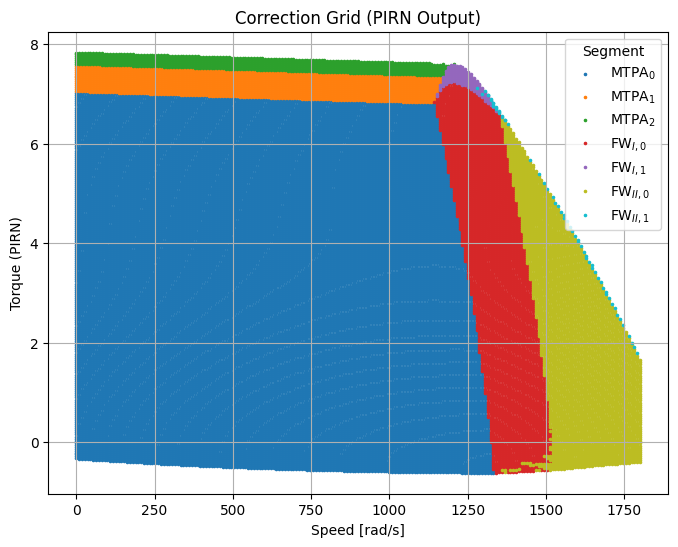


--- Plotting Residual Torque Error ---


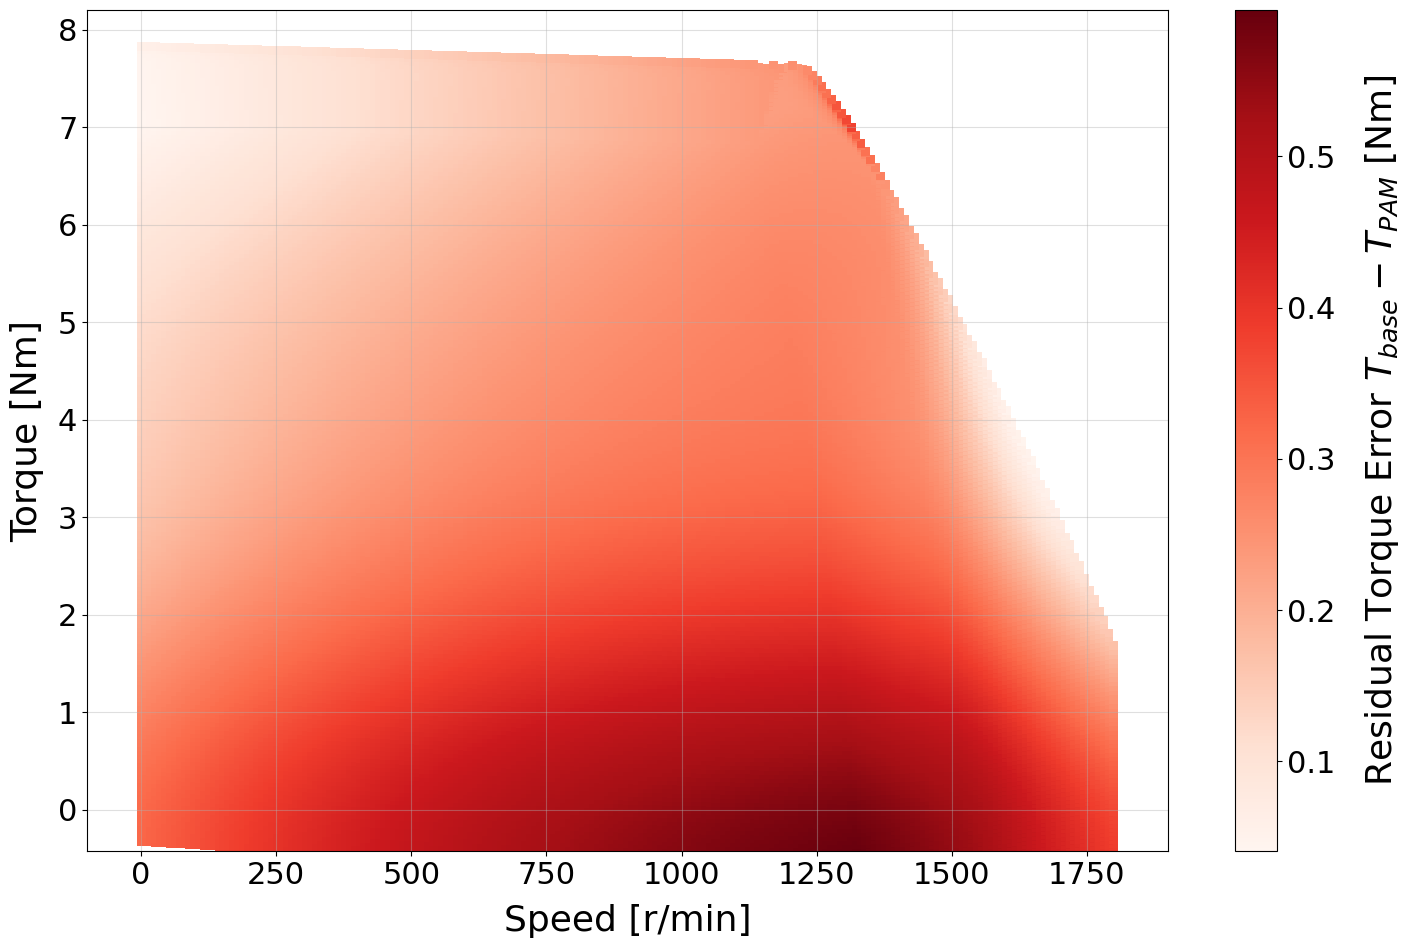


--- Calculating Compensated Grid ---
Loading Compensated Grid...
Plotting Compensated Grid...


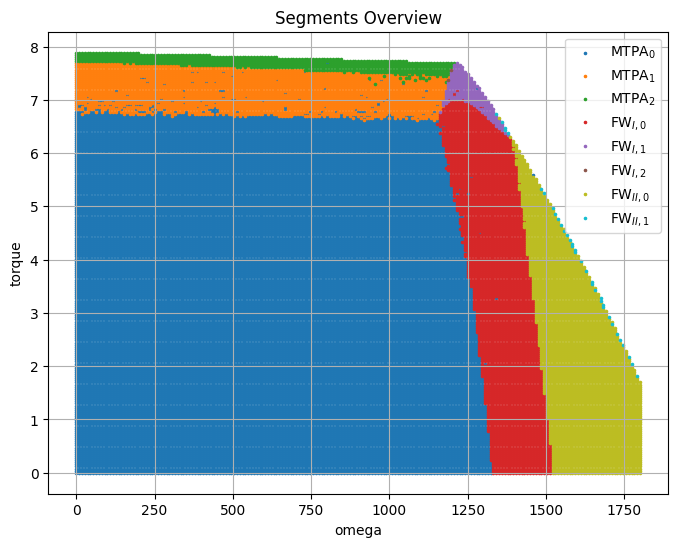


--- Calculating Recalculated Grid ---
Loading Recalculated Grid...
Processing Recalculated Data for Plotting...
Torque values updated with PIRN predictions.
Plotting Recalculated Grid...


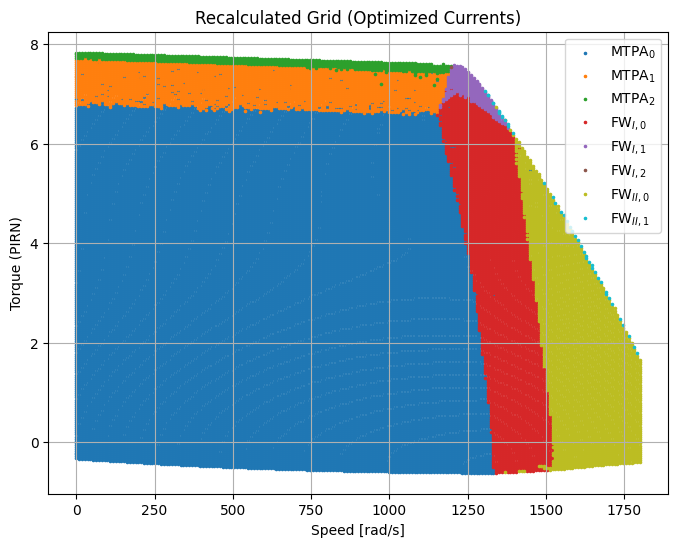


--- Plotting Current Trajectories ---


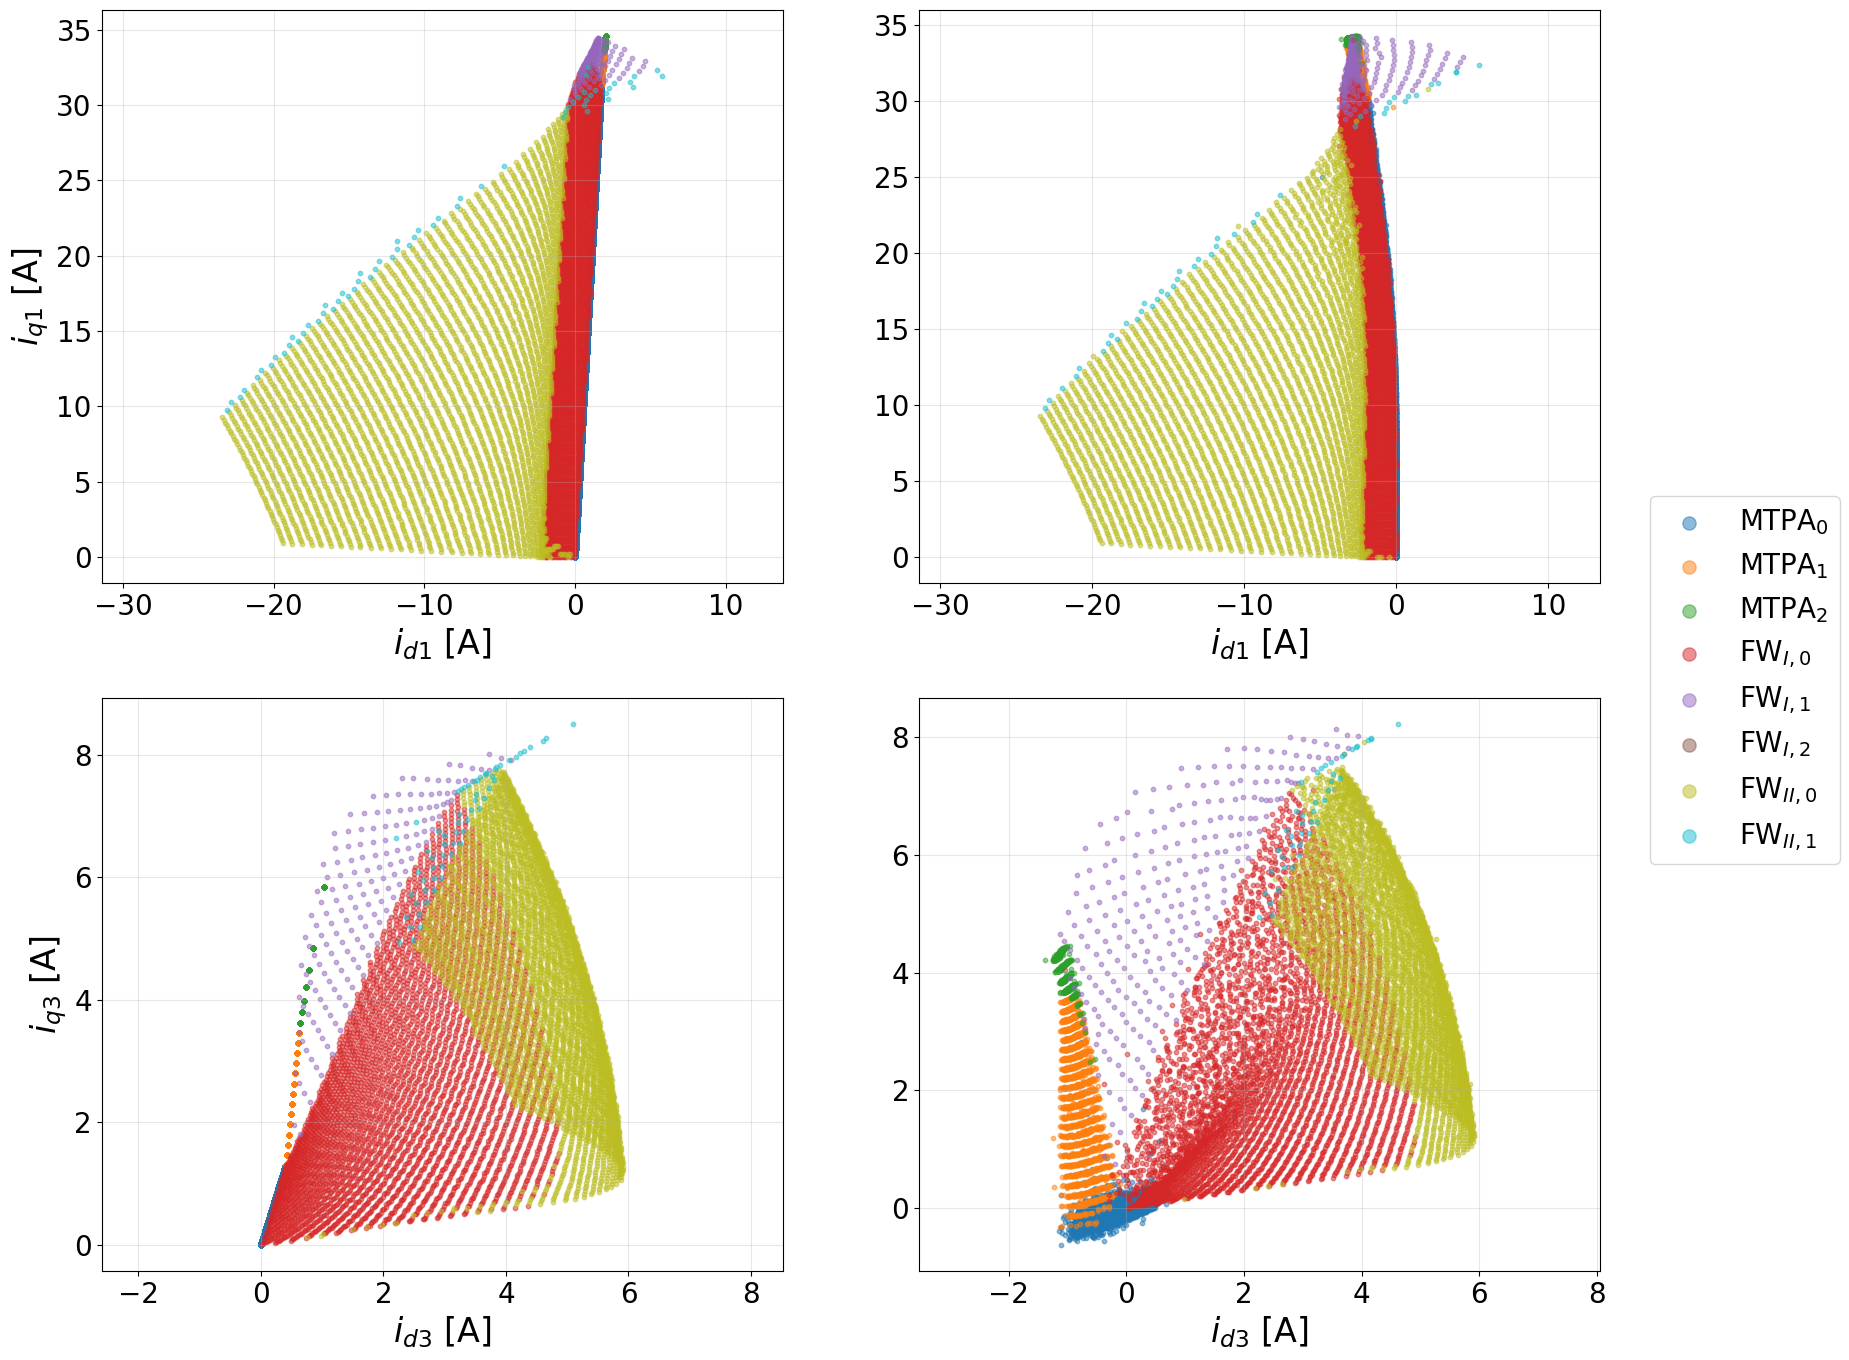


--- Plotting Joule Losses Reduction ---


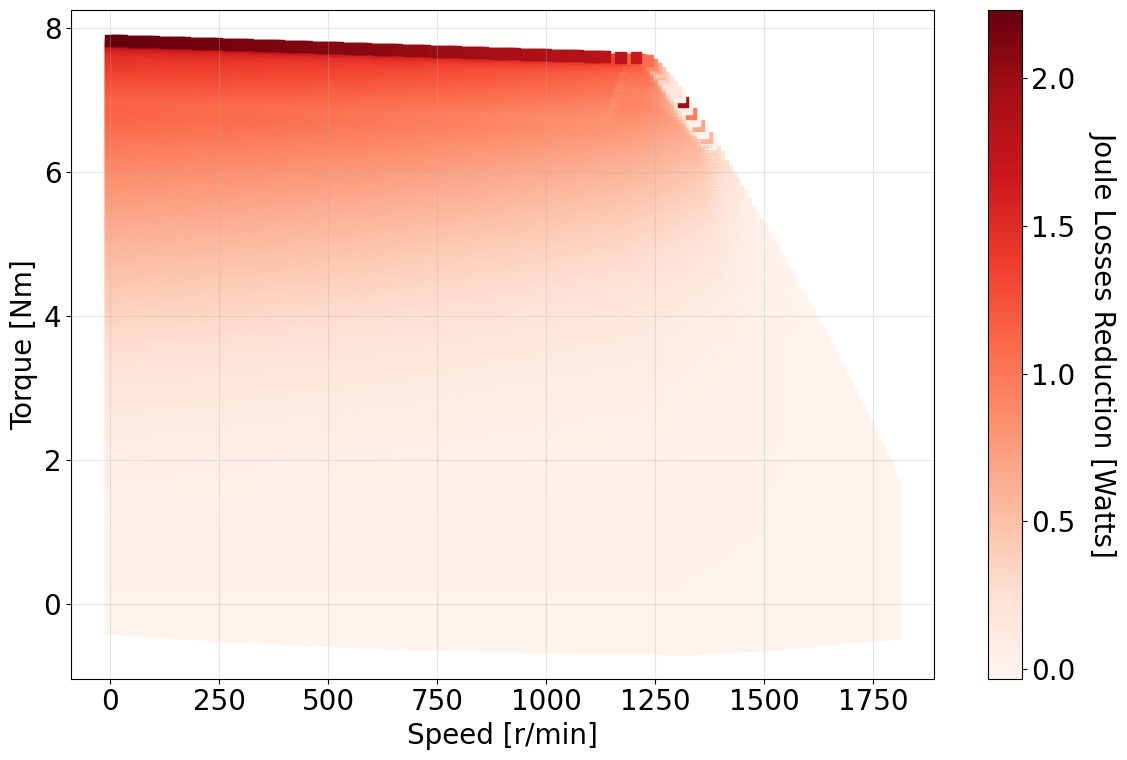

Analysis Complete. Max savings: 2.23 W


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pmsm_lib.machines import PMSM_IEEETIE_machine2
from pmsm_lib.physics import Transform
from pmsm_lib.neural import load_pirn_model
from pmsm_lib.grid import grid_calc, grid_calc_Compensated, grid_to_data, grid_calc_Recalculated
from pmsm_lib.plotting import  plot_grid_segments
from pmsm_lib.optimization import predict_torque_pirn


OUT_FOLDER = './data'
DATA_FOLDER = './data/250416_mereni/'
CSV_PATH = './aggregated_file_means.csv'

BASELINE_FILE = os.path.join(OUT_FOLDER, 'IEEETIE_machine2_baseline.pkl')
CORRECTION_FILE = os.path.join(OUT_FOLDER, 'IEEETIE_machine2_correction.pkl')
COMP_FILE = os.path.join(OUT_FOLDER, 'IEEETIE_machine2_compensated.pkl')
RECALC_FILE = os.path.join(OUT_FOLDER, 'IEEETIE_machine2_recalculated.pkl')

PIRN_WEIGHTS = 'PIRN_Best_H6_LR15e-2_Reg2e-4.pth'
PIRN_SCALER = 'PIRN_Best_H6_LR15e-2_Reg2e-4_scaler.npy'
DEVICE = torch.device("cpu")

POLE_PAIRS = 8  
TO_RPM = 30 / (np.pi * POLE_PAIRS)

CALC_OPTS = {
    'n_T': 201, 'n_om': 201,
    'min_T': 0, 'min_om': 0,
    'opts': {'disp': False, 'ftol': 1e-8, 'maxiter': 500, 'eps': 1e-8}
}
K_SKIP = 1

# ==========================================
# 1. INITIALIZE MODELS 
# ==========================================
print("Initializing models...")
if not os.path.exists(OUT_FOLDER):
    os.makedirs(OUT_FOLDER)

ipm_model = PMSM_IEEETIE_machine2()
ipm_model.set_max_pars(Imax=30, Umax=13, nmax=1800)
W = Transform(ipm_model, 0, False)

pirn_model, scaler = load_pirn_model(
    PIRN_WEIGHTS, PIRN_SCALER, 
    hidden_size=12, input_size=5, 
    ipm_model=ipm_model, device=DEVICE
)

# ==========================================
# 2. PARITY PLOT 
# ==========================================
print("\n--- Running Parity Plot Analysis ---")
print("Loading and splitting data...")
df_full = pd.read_csv(CSV_PATH).dropna(subset=['id1', 'iq1', 'id3', 'iq3', 'torq', 'omega'])
df_full = df_full.rename(columns={'torq': 'T_measured'})

df_train, df_test = train_test_split(df_full, test_size=0.15, random_state=42)

def evaluate_dataset(df):
    """Runs a given dataframe through both models and returns the predictions and errors."""
    df = df.copy()
    
    # Analytical
    currents = df[['id1', 'iq1', 'id3', 'iq3']].to_numpy()
    A_i = currents @ ipm_model.A
    df['T_model'] = np.einsum('ij, ij -> i', currents, A_i) + 2 * (currents @ ipm_model.b)
    df['Error_Analytical'] = df['T_model'] - df['T_measured']

    # PIRN
    X_features = df[['omega', 'id1', 'iq1', 'id3', 'iq3']].values
    X_scaled = scaler.transform(X_features)
    X_tensor = torch.from_numpy(X_scaled).float().to(DEVICE)
    with torch.no_grad():
        df['T_pirn'] = pirn_model(X_tensor).cpu().numpy().flatten()
    df['Error_PIRN'] = df['T_pirn'] - df['T_measured']
    
    return df

print("Evaluating models...")
df_train_eval = evaluate_dataset(df_train)
df_test_eval = evaluate_dataset(df_test)

rmse_ana_test = np.sqrt(np.mean(df_test_eval['Error_Analytical']**2))
rmse_pirn_test = np.sqrt(np.mean(df_test_eval['Error_PIRN']**2))

print("Generating Parity Plot...")
with plt.rc_context({
    'font.size': 20,          
    'axes.labelsize': 22,     
    'xtick.labelsize': 20,    
    'ytick.labelsize': 20,    
    'legend.fontsize': 18,    
}):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

    all_t = np.concatenate([df_full['T_measured'], df_train_eval['T_model'], df_train_eval['T_pirn']])
    min_val = all_t.min() - 0.5
    max_val = all_t.max() + 0.5

    # Plot 1: Analytical Model
    axes[0].scatter(df_train_eval['T_measured'], df_train_eval['T_model'], 
                    facecolors='none', edgecolors='blue', alpha=0.3, s=80, lw=1.5, label='Training Data')
    axes[0].scatter(df_test_eval['T_measured'], df_test_eval['T_model'], 
                    color='blue', alpha=0.9, s=100, label=f'Test Data\n(RMSE: {rmse_ana_test:.3f})')
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=3)
    axes[0].set_xlabel('Measured Torque [Nm]')
    axes[0].set_ylabel('Predicted Torque [Nm]')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left')

    # Plot 2: PIRN Model
    axes[1].scatter(df_train_eval['T_measured'], df_train_eval['T_pirn'], 
                    facecolors='none', edgecolors='green', alpha=0.3, s=80, lw=1.5, label='Training Data')
    axes[1].scatter(df_test_eval['T_measured'], df_test_eval['T_pirn'], 
                    color='green', alpha=0.9, s=100, label=f'Test Data\n(RMSE: {rmse_pirn_test:.3f})')
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=3)
    axes[1].set_xlabel('Measured Torque [Nm]')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# ==========================================
# 3. BASELINE GRID 
# ==========================================
print("\n--- Calculating Baseline Grid ---")
if not os.path.exists(BASELINE_FILE):
    print("Calculating Baseline...")
    base_grid = grid_calc(ipm_model, W, CALC_OPTS)
    with open(BASELINE_FILE, 'wb') as f:
        pickle.dump(base_grid, f)
else:
    print("Loading Baseline...")
    with open(BASELINE_FILE, 'rb') as f:
        base_grid = pickle.load(f)

print("Plotting Baseline...")
data_base = grid_to_data(base_grid, K_SKIP)
plot_grid_segments(data_base)

# ==========================================
# 4. CORRECTION GRID 
# ==========================================
print("\n--- Calculating Correction Grid (PIRN Output) ---")
if not os.path.exists(CORRECTION_FILE):
    print("Calculating Correction Grid Matrix...")
    corr_grid = {k: v.copy() if isinstance(v, np.ndarray) else v for k, v in base_grid.items()}

    n_T = len(corr_grid['T'])
    n_om = len(corr_grid['om_vec'])
    corr_grid['T_pirn_matrix'] = np.full((n_T, n_om), np.nan)

    for k_om in range(n_om):
        omega_val = corr_grid['om_vec'][k_om]
        for k_T in range(n_T):
            if np.isnan(corr_grid['isd1'][k_T, k_om]):
                continue
            is_vec = np.array([
                corr_grid['isd1'][k_T, k_om], corr_grid['isq1'][k_T, k_om],
                corr_grid['isd3'][k_T, k_om], corr_grid['isq3'][k_T, k_om]
            ])
            t_pred = predict_torque_pirn(is_vec, omega_val, pirn_model, scaler, DEVICE)
            corr_grid['T_pirn_matrix'][k_T, k_om] = t_pred

    print("Saving Correction Grid...")
    with open(CORRECTION_FILE, 'wb') as f:
        pickle.dump(corr_grid, f)
else:
    print("Loading Correction Grid...")
    with open(CORRECTION_FILE, 'rb') as f:
        corr_grid = pickle.load(f)

print("Plotting Correction Grid (Y-Axis = PIRN Output)...")
data_corr = grid_to_data(corr_grid, K_SKIP)

try:
    n_rows = data_corr.isd1.shape[0]
    omega_2d = np.tile(data_corr.omega, (n_rows, 1))

    omega_flat = omega_2d.flatten()
    id1_flat = data_corr.isd1.flatten()
    iq1_flat = data_corr.isq1.flatten()
    id3_flat = data_corr.isd3.flatten()
    iq3_flat = data_corr.isq3.flatten()

    valid_mask = ~np.isnan(id1_flat)
    T_pirn_flat = np.full_like(id1_flat, np.nan)

    if np.any(valid_mask):
        X_in = np.stack([
            omega_flat[valid_mask],
            id1_flat[valid_mask], iq1_flat[valid_mask],
            id3_flat[valid_mask], iq3_flat[valid_mask]
        ], axis=1)

        X_scaled = scaler.transform(X_in)
        X_tensor = torch.from_numpy(X_scaled).float().to(DEVICE)
        with torch.no_grad():
            preds = pirn_model(X_tensor).cpu().numpy().flatten()
        T_pirn_flat[valid_mask] = preds

    T_pirn_2d = T_pirn_flat.reshape(data_corr.isd1.shape)

    colors_map = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728',
                  4: '#9467bd', 5: '#8c564b', 6: '#bcbd22', 7: '#17becf', 8: '#7f7f7f'}
    
    labels_map = {0: r'MTPA$_{0}$', 1: r'MTPA$_{1}$', 2: r'MTPA$_{2}$',
                  3: r'FW$_{I,0}$', 4: r'FW$_{I,1}$', 5: r'FW$_{I,2}$',
                  6: r'FW$_{II,0}$', 7: r'FW$_{II,1}$'}

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title("Correction Grid (PIRN Output)")
    ax.set_xlabel('Speed [rad/s]')
    ax.set_ylabel('Torque (PIRN)')

    for i_seg in range(1, data_corr.n_seg + 1):
        seg_val = int(data_corr.i_to_seg[i_seg])
        color = colors_map.get(seg_val, 'black')
        label_name = labels_map.get(seg_val, str(seg_val))
        
        r = data_corr.rows[i_seg]
        c = data_corr.cols[i_seg]
        ax.scatter(data_corr.omega[c], T_pirn_2d[r, c], s=10, c=color, marker='.', label=label_name)
    
    handles, labels = ax.get_legend_handles_labels()
    unique_legend = dict(zip(labels, handles))
    ax.legend(unique_legend.values(), unique_legend.keys(), title='Segment', loc='best')
    ax.grid(True)
    plt.show()

except Exception as e:
    print(f"Error in Correction Plot: {e}")
    plot_grid_segments(data_corr)

# ==========================================
# 5. RESIDUAL TORQUE ERROR 
# ==========================================
print("\n--- Plotting Residual Torque Error ---")
omega_raw   = base_grid['om_vec']
omega_rpm   = omega_raw * TO_RPM
T_target_1d = base_grid['T']
T_target_2d = np.tile(T_target_1d[:, np.newaxis], (1, len(omega_rpm)))
T_actual_2d = corr_grid['T_pirn_matrix']

valid_mask = ~np.isnan(base_grid['isd1'])
T_diff = np.where(valid_mask, T_target_2d - T_actual_2d, np.nan)

omega_2d = np.tile(omega_rpm[np.newaxis, :], (len(T_target_1d), 1))
valid_flat = valid_mask.ravel()
x_vals = omega_2d.ravel()[valid_flat]
y_vals = T_actual_2d.ravel()[valid_flat]   
c_vals = T_diff.ravel()[valid_flat]

with plt.rc_context({
    'font.size': 24,
    'axes.labelsize': 26,
    'axes.titlesize': 26,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'figure.titlesize': 28
}):
    fig, ax = plt.subplots(figsize=(15, 10))

    sc = ax.scatter(
        x_vals, y_vals, c=c_vals,
        cmap='Reds',
        s=40,            
        marker='s',      
        linewidths=0
    )

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label('Residual Torque Error $T_{base} - T_{PAM}$ [Nm]', size=26, labelpad=20)
    cbar.ax.tick_params(labelsize=22)

    ax.set_xlim([-100, 1900])
    ax.set_ylim([-0.425, 8.2])
    ax.set_xlabel('Speed [r/min]', labelpad=10)
    ax.set_ylabel('Torque [Nm]', labelpad=10)
    ax.grid(True, which='both', linestyle='-', alpha=0.4)

    plt.tight_layout()
    plt.show()

# ==========================================
# 6. COMPENSATED GRID
# ==========================================
print("\n--- Calculating Compensated Grid ---")
CALC_OPTS_PIRN = CALC_OPTS.copy()
CALC_OPTS_PIRN['opts'] = {'disp': False, 'ftol': 1e-5, 'maxiter': 2500, 'eps': 5e-4}

if not os.path.exists(COMP_FILE):
    print("Calculating Compensated Grid...")
    comp_grid = grid_calc_Compensated(
        ipm_model, W, CALC_OPTS_PIRN,
        pirn_model, scaler, DEVICE
    )
    with open(COMP_FILE, 'wb') as f:
        pickle.dump(comp_grid, f)
else:
    print("Loading Compensated Grid...")
    with open(COMP_FILE, 'rb') as f:
        comp_grid = pickle.load(f)

print("Plotting Compensated Grid...")
data_comp = grid_to_data(comp_grid, K_SKIP)
plot_grid_segments(data_comp)

# ==========================================
# 7. RECALCULATED GRID
# ==========================================
print("\n--- Calculating Recalculated Grid ---")
if not os.path.exists(RECALC_FILE):
    print("Calculating Recalculated Grid...")
    recalc_grid = grid_calc_Recalculated(
        ipm_model, W, CALC_OPTS_PIRN,
        pirn_model, scaler, DEVICE,
        corr_grid
    )
    with open(RECALC_FILE, 'wb') as f:
        pickle.dump(recalc_grid, f)
else:
    print("Loading Recalculated Grid...")
    with open(RECALC_FILE, 'rb') as f:
        recalc_grid = pickle.load(f)

print("Processing Recalculated Data for Plotting...")
data_recalc = grid_to_data(recalc_grid, K_SKIP)

try:
    n_rows = data_recalc.isd1.shape[0]
    omega_2d_recalc = np.tile(data_recalc.omega, (n_rows, 1))

    omega_flat_r = omega_2d_recalc.flatten()
    id1_flat_r = data_recalc.isd1.flatten()
    iq1_flat_r = data_recalc.isq1.flatten()
    id3_flat_r = data_recalc.isd3.flatten()
    iq3_flat_r = data_recalc.isq3.flatten()

    valid_mask_r = ~np.isnan(id1_flat_r)
    T_recalc_flat = np.full_like(id1_flat_r, np.nan)

    if np.any(valid_mask_r):
        X_in_r = np.stack([
            omega_flat_r[valid_mask_r],
            id1_flat_r[valid_mask_r], iq1_flat_r[valid_mask_r],
            id3_flat_r[valid_mask_r], iq3_flat_r[valid_mask_r]
        ], axis=1)

        X_scaled_r = scaler.transform(X_in_r)
        X_tensor_r = torch.from_numpy(X_scaled_r).float().to(DEVICE)
        with torch.no_grad():
            preds_r = pirn_model(X_tensor_r).cpu().numpy().flatten()

        T_recalc_flat[valid_mask_r] = preds_r

    data_recalc.T = T_recalc_flat.reshape(data_recalc.isd1.shape)
    print("Torque values updated with PIRN predictions.")

except Exception as e:
    print(f"Warning: Could not update Torque with PIRN values. Plot may be inaccurate. {e}")

print("Plotting Recalculated Grid...")
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Recalculated Grid (Optimized Currents)")
ax.set_xlabel('Speed [rad/s]')
ax.set_ylabel('Torque (PIRN)')

colors_map = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728',
              4: '#9467bd', 5: '#8c564b', 6: '#bcbd22', 7: '#17becf', 8: '#7f7f7f'}

labels_map = {0: r'MTPA$_{0}$', 1: r'MTPA$_{1}$', 2: r'MTPA$_{2}$',
              3: r'FW$_{I,0}$', 4: r'FW$_{I,1}$', 5: r'FW$_{I,2}$',
              6: r'FW$_{II,0}$', 7: r'FW$_{II,1}$'}

for i_seg in range(1, data_recalc.n_seg + 1):
    seg_val = int(data_recalc.i_to_seg[i_seg])
    color = colors_map.get(seg_val, 'black')
    label_name = labels_map.get(seg_val, str(seg_val))
    
    r = data_recalc.rows[i_seg]
    c = data_recalc.cols[i_seg]
    x_vals_r = data_recalc.omega[c]
    y_vals_r = data_recalc.T[r, c]
    ax.scatter(x_vals_r, y_vals_r, s=10, c=color, marker='.', label=label_name)

handles, labels = ax.get_legend_handles_labels()
unique_legend = dict(zip(labels, handles))
ax.legend(unique_legend.values(), unique_legend.keys(), loc='best')
ax.grid(True)
plt.show()

# ==========================================
# 8. CURRENT TRAJECTORIES PLOT
# ==========================================
def plot_current_trajectories_split(data_analytical, data_recalc):
    colors_map = {0: '#1f77b4', 1: '#ff7f0e', 2: '#2ca02c', 3: '#d62728',
                  4: '#9467bd', 5: '#8c564b', 6: '#bcbd22', 7: '#17becf', 8: '#7f7f7f'}
                  
    labels_map = {0: r'MTPA$_{0}$', 1: r'MTPA$_{1}$', 2: r'MTPA$_{2}$',
                  3: r'FW$_{I,0}$', 4: r'FW$_{I,1}$', 5: r'FW$_{I,2}$',
                  6: r'FW$_{II,0}$', 7: r'FW$_{II,1}$'}

    with plt.rc_context({
        'font.size': 20,
        'axes.labelsize': 24,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 20,
        'legend.title_fontsize': 24
    }):
        fig, axes = plt.subplots(2, 2, figsize=(18, 14))

        def run_segment_plotting(ax, data_obj, d_comp, q_comp):
            for i_seg in range(1, data_obj.n_seg + 1):
                seg_val = int(data_obj.i_to_seg[i_seg])
                color = colors_map.get(seg_val, 'black')
                label_name = labels_map.get(seg_val, str(seg_val))
                
                r_idx = data_obj.rows[i_seg]
                c_idx = data_obj.cols[i_seg]

                x_vals_seg = getattr(data_obj, d_comp)[r_idx, c_idx]
                y_vals_seg = getattr(data_obj, q_comp)[r_idx, c_idx]

                isd1_ref = data_obj.isd1[r_idx, c_idx]
                mask = ~np.isnan(isd1_ref)

                if np.any(mask):
                    ax.scatter(x_vals_seg[mask], y_vals_seg[mask],
                               s=40, c=color, marker='.', alpha=0.5,
                               label=label_name)

            ax.grid(True, alpha=0.3)
            ax.axis('equal')

        run_segment_plotting(axes[0, 0], data_analytical, 'isd1', 'isq1')
        run_segment_plotting(axes[0, 1], data_recalc,     'isd1', 'isq1')
        run_segment_plotting(axes[1, 0], data_analytical, 'isd3', 'isq3')
        run_segment_plotting(axes[1, 1], data_recalc,     'isd3', 'isq3')

        axes[0, 0].set_ylabel("$i_{q1}$ [A]")
        axes[1, 0].set_ylabel("$i_{q3}$ [A]")
        axes[0, 0].set_xlabel("$i_{d1}$ [A]")
        axes[0, 1].set_xlabel("$i_{d1}$ [A]")
        axes[1, 0].set_xlabel("$i_{d3}$ [A]")
        axes[1, 1].set_xlabel("$i_{d3}$ [A]")

        by_label = {}
        for ax in axes.flat:
            handles, labels = ax.get_legend_handles_labels()
            for h, l in zip(handles, labels):
                if l not in by_label:
                    by_label[l] = h

        def get_sort_key(lbl):
            for k, v in labels_map.items():
                if v == lbl:
                    return k
            return 999 

        sorted_labels = sorted(by_label.keys(), key=get_sort_key)
        sorted_handles = [by_label[l] for l in sorted_labels]

        fig.legend(sorted_handles, sorted_labels,
                   loc='center left', bbox_to_anchor=(0.92, 0.5),
                   markerscale=3)

        plt.tight_layout()
        plt.subplots_adjust(right=0.90, hspace=0.2, wspace=0.2)
        plt.show()

print("\n--- Plotting Current Trajectories ---")
plot_current_trajectories_split(data_corr, data_recalc)

# ==========================================
# 9. JOULE LOSSES PLOT
# ==========================================
def plot_five_phase_losses(data_corr, data_recalc):
    Rs = 0.021  
    k = 2.5     

    with plt.rc_context({'font.size': 20}):
        mask_base = ~np.isnan(data_corr.isd1)
        mask_recalc = ~np.isnan(data_recalc.isd1)
        common_mask = mask_base & mask_recalc

        if not np.any(common_mask):
            print("No overlapping data points found.")
            return

        n_rows, n_cols = data_recalc.isd1.shape
        rows, cols = np.indices((n_rows, n_cols))

        flat_mask = common_mask.flatten()
        r_valid = rows.flatten()[flat_mask]
        c_valid = cols.flatten()[flat_mask]

        x_plot = data_recalc.omega[c_valid]
        y_plot = data_recalc.T[r_valid, c_valid]

        def calc_p_loss(dataset, r, c):
            sq_sum = (dataset.isd1[r, c]**2 + dataset.isq1[r, c]**2 +
                      dataset.isd3[r, c]**2 + dataset.isq3[r, c]**2)
            return k * Rs * sq_sum

        P_loss_base   = calc_p_loss(data_corr,   r_valid, c_valid)
        P_loss_recalc = calc_p_loss(data_recalc, r_valid, c_valid)
        P_diff = P_loss_base - P_loss_recalc

        plt.figure(figsize=(12, 8))
        sc = plt.scatter(x_plot, y_plot, c=P_diff, cmap='Reds', s=60, marker='s')
        cbar = plt.colorbar(sc)
        cbar.set_label('Joule Losses Reduction [Watts]', rotation=270, labelpad=30)
        plt.xlabel("Speed [r/min]")
        plt.ylabel("Torque [Nm]")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Analysis Complete. Max savings: {np.max(P_diff):.2f} W")

print("\n--- Plotting Joule Losses Reduction ---")
plot_five_phase_losses(data_corr, data_recalc)